# 08G – Fairness & Bias Assessment

Enterprise notebook for assessing whether the bankruptcy prediction model performs consistently across different groups.

## Business Objective
Evaluate whether model performance differs across meaningful subgroups and identify potential sources of unfair or biased predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
DATA_PATH='../data/datasets/american_bankruptcy_cleaned.csv'
MODEL_PATH='../models/production_bankruptcy_model.joblib'

df=pd.read_csv(DATA_PATH)

if 'status_label' in df.columns:
    y=df['status_label'].map({'alive':0,'failed':1})
    X=df.drop(columns=[col for col in ['status_label','company_name'] if col in df.columns])
elif 'target' in df.columns:
    y=df['target']
    X=df.drop(columns=[col for col in ['target','company_name'] if col in df.columns])
else:
    raise ValueError('Target column not found')

# Use the first numeric feature as an example grouping variable.
group_feature=X.select_dtypes(include='number').columns[0]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

model=joblib.load(MODEL_PATH)
pred=model.predict(X_test)

test=X_test.copy()
test['Actual']=y_test.values
test['Predicted']=pred
test['Group']=np.where(
    test[group_feature]>=test[group_feature].median(),
    'High','Low')


In [3]:
rows=[]
for g,data in test.groupby('Group'):
    rows.append({
        'Group':g,
        'Samples':len(data),
        'Accuracy':accuracy_score(data['Actual'],data['Predicted']),
        'Precision':precision_score(data['Actual'],data['Predicted'],zero_division=0),
        'Recall':recall_score(data['Actual'],data['Predicted'],zero_division=0),
        'F1':f1_score(data['Actual'],data['Predicted'],zero_division=0)
    })

fairness=pd.DataFrame(rows)
fairness.to_csv('fairness_metrics.csv',index=False)
fairness

,Group,Samples,Accuracy,Precision,Recall,F1
0,High,8325,0.954234,0.662791,0.139364,0.230303
1,Low,7412,0.922153,0.719697,0.149606,0.247718


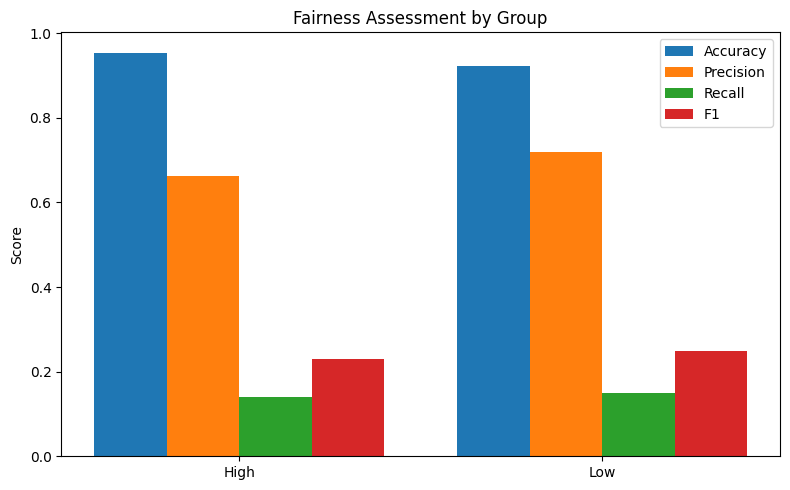

In [4]:
plt.figure(figsize=(8,5))
x=np.arange(len(fairness))
w=0.2

for i,m in enumerate(['Accuracy','Precision','Recall','F1']):
    plt.bar(x+i*w,fairness[m],w,label=m)

plt.xticks(x+1.5*w,fairness['Group'])
plt.ylabel('Score')
plt.title('Fairness Assessment by Group')
plt.legend()
plt.tight_layout()
plt.savefig('fairness_assessment.png',dpi=300)
plt.show()

## Business Interpretation

- Similar performance across groups indicates lower evidence of systematic bias.
- Large differences in Precision, Recall, or F1 may indicate that certain groups receive disproportionately different predictions.
- For regulated financial applications, fairness should be evaluated using appropriate protected attributes when legally and ethically available.

## Deliverables

- `fairness_metrics.csv`
- `fairness_assessment.png`

This notebook provides a baseline fairness assessment. In production, demographic or regulatory protected attributes should be used where permitted for a comprehensive bias audit.